In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/clean_customers.csv')
print(df.shape)

(10127, 25)


In [2]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Encoding:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done ✅")

Encoding: ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Encoding done ✅


In [3]:
drop_cols = ['Churn', 'CLIENTNUM', 'Attrition_Flag']
X = df.drop(columns=drop_cols)
y = df['Churn']

print("Features:", X.shape)
print("Target distribution:\n", y.value_counts())

Features: (10127, 22)
Target distribution:
 Churn
0    8500
1    1627
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8101, 22)
Test size: (2026, 22)


In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1701
           1       0.81      0.61      0.69       325

    accuracy                           0.91      2026
   macro avg       0.87      0.79      0.82      2026
weighted avg       0.91      0.91      0.91      2026

ROC-AUC: 0.9287


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1701
           1       0.95      0.80      0.87       325

    accuracy                           0.96      2026
   macro avg       0.96      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026

ROC-AUC: 0.9879


In [8]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1701
           1       0.95      0.87      0.91       325

    accuracy                           0.97      2026
   macro avg       0.96      0.93      0.95      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC: 0.9932


In [9]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_proba), 4),
        round(roc_auc_score(y_test, rf_proba), 4),
        round(roc_auc_score(y_test, xgb_proba), 4)
    ]
})
print(results)
results.to_csv('../reports/model_comparison.csv', index=False)

                 Model  ROC-AUC
0  Logistic Regression   0.9287
1        Random Forest   0.9879
2              XGBoost   0.9932


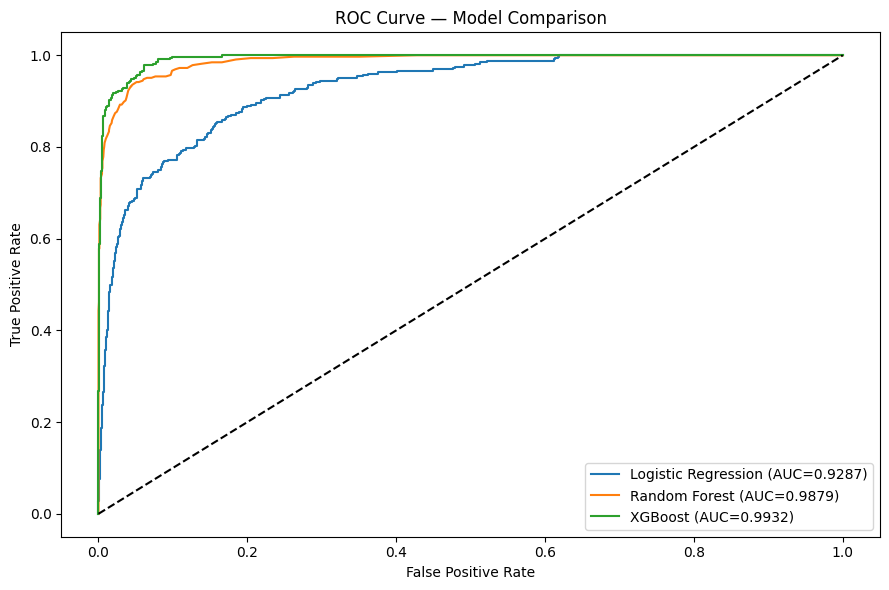

In [10]:
plt.figure(figsize=(9, 6))
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest', rf_proba),
                    ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = round(roc_auc_score(y_test, proba), 4)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/09_roc_curve.png', dpi=150)
plt.show()

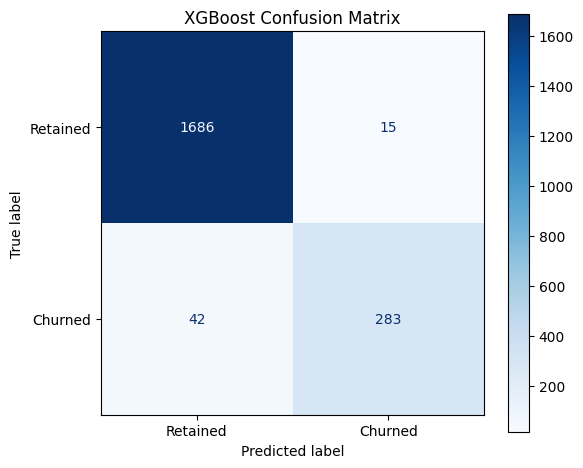

In [11]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_preds, ax=ax,
    display_labels=['Retained', 'Churned'], cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/10_confusion_matrix.png', dpi=150)
plt.show()

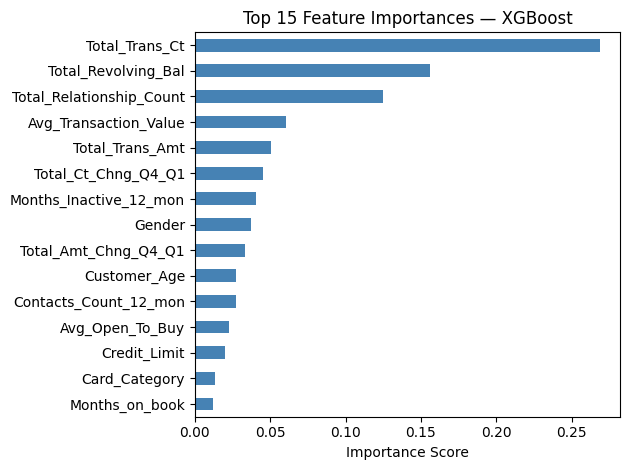


Top 5 churn drivers:
Total_Trans_Ct              0.268646
Total_Revolving_Bal         0.155877
Total_Relationship_Count    0.124612
Avg_Transaction_Value       0.060556
Total_Trans_Amt             0.050857
dtype: float32


In [12]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/11_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 churn drivers:")
print(feat_imp.head())

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

print("5-Fold CV ROC-AUC Scores:", cv_scores.round(4))
print("Mean AUC:", round(cv_scores.mean(), 4))
print("Std Dev:", round(cv_scores.std(), 4))

# Save CV results
cv_df = pd.DataFrame({
    'Fold': range(1, 6),
    'ROC-AUC': cv_scores.round(4)
})
cv_df.loc[len(cv_df)] = ['Mean', round(cv_scores.mean(), 4)]
cv_df.to_csv('../reports/cv_scores.csv', index=False)

# Save feature importance
feat_imp_full = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp_full = feat_imp_full.sort_values(ascending=False)
feat_imp_full.to_csv('../reports/feature_importance.csv', header=['importance'])
print("\nResults saved to reports/")

5-Fold CV ROC-AUC Scores: [0.9902 0.9952 0.9904 0.9932 0.9954]
Mean AUC: 0.9929
Std Dev: 0.0022

Results saved to reports/
